In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd

buildings = pd.read_parquet("drive/MyDrive/War_Damage/datasets/Gaza_20240503_320a78e597.parquet")
print(buildings.head())

                system:index        area building  class  damage_pts  \
84828   0000000000000001a92b  197.190264      yes      0           0   
85309   0000000000000001ac98   81.970637      yes      0           0   
38485   000000000000000094b1  168.487653      yes      1           3   
167449  0000000000000003a75c  196.371639      yes      1           1   
15631   00000000000000000f37   56.694041      yes      1           3   

            k100      k150       k50  max_change  name      osm_id   osm_type  \
84828   2.525898  2.655475  2.541702    2.131464  None   306990965  ways_poly   
85309   2.595308  2.474266  2.472051    2.096974  None  1287323523  ways_poly   
38485   3.539992  3.512826  3.528040    2.996506  None   296103094  ways_poly   
167449  2.526029  2.853601  2.417009    1.687505  None  1257227431  ways_poly   
15631   4.753665  5.144150  4.965874    4.707861  None   299416191  ways_poly   

                                                 geometry  
84828   b'\x01\x03\x

In [ ]:
import numpy as np

npz_file_path = "/content/drive/MyDrive/War_Damage/datasets/Gaza_20240503_320a78e597.npz"

try:
    # Load the .npz file
    with np.load(npz_file_path) as data:
        print(f"Keys found in the .npz file: {list(data.keys())}")

        # Access the first entry. Assuming the first key holds the relevant data.
        # If there are multiple keys, you might need to specify which one to access.
        if data.keys():
            first_key = list(data.keys())[0]
            first_entry = data[first_key]
            print(f"\nShape of the first entry ('{first_key}'): {first_entry.shape}")
            print(f"Data type of the first entry ('{first_key}'): {first_entry.dtype}")
            print(f"\nFirst 5 values of the first entry ('{first_key}'):\n{first_entry.flatten()[:5]}")

            # You can also check if it's a TIFF-like structure (e.g., 3D array for image data)
            if len(first_entry.shape) >= 2:
                print("This entry appears to be multi-dimensional, potentially image data like TIFFs.")
            else:
                print("This entry appears to be a 1D array.")
        else:
            print("The .npz file is empty or contains no arrays.")
except FileNotFoundError:
    print(f"Error: The file {npz_file_path} was not found. Please ensure the path is correct and your drive is mounted properly.")
except Exception as e:
    print(f"An error occurred while reading the .npz file: {e}")

Keys found in the .npz file: ['X', 'tab', 'y', 'lat', 'channel_names']

Shape of the first entry ('X'): (4000, 14, 32, 32)
Data type of the first entry ('X'): float16

First 5 values of the first entry ('X'):
[1449. 1460. 1464. 1444. 1449.]
This entry appears to be multi-dimensional, potentially image data like TIFFs.


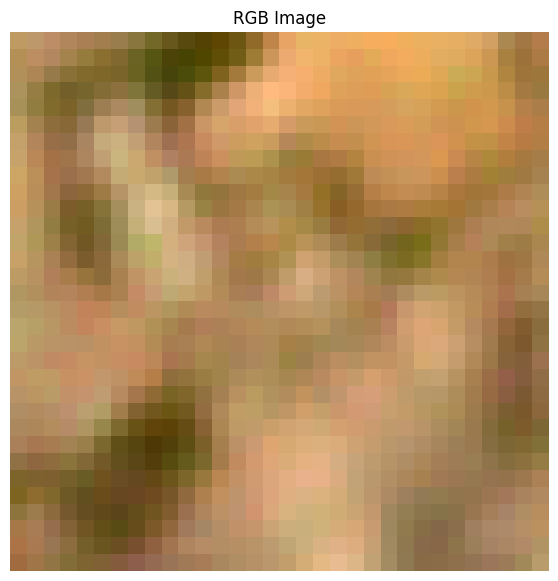

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Re-load the .npz file to ensure we have 'first_entry' and 'channel_names'
npz_file_path = "/content/drive/MyDrive/War_Damage/datasets/Gaza_20240503_320a78e597.npz"
with np.load(npz_file_path) as data:
    if 'X' in data and 'channel_names' in data:
        first_entry = data['X']
        channel_names = [name.strip() for name in data['channel_names'].tolist()] # Ensure names are clean
    else:
        print("Error: 'X' or 'channel_names' not found in the .npz file.")
        # Fallback if channel_names is missing (though it was present in output)
        channel_names = [f'Channel {i+1}' for i in range(first_entry.shape[1])]

if 'first_entry' in locals() and first_entry.ndim == 4:
    first_image_all_channels = first_entry[0] # Shape (14, 32, 32)

    # Find indices for B, G, R channels
    try:
        idx_b = channel_names.index('ps_post_B')
        idx_g = channel_names.index('ps_post_G')
        idx_r = channel_names.index('ps_post_R')

        # Extract the B, G, R channels
        b_channel = first_image_all_channels[idx_b]
        g_channel = first_image_all_channels[idx_g]
        r_channel = first_image_all_channels[idx_r]

        # Stack them to form an RGB image. Matplotlib expects (H, W, C) format.
        rgb_image = np.stack([r_channel, g_channel, b_channel], axis=-1)

        # Ensure no NaN values are present before normalization
        if np.isnan(rgb_image).any():
            print("Warning: NaN values found in rgb_image before normalization. Replacing with 0.")
            rgb_image = np.nan_to_num(rgb_image, nan=0.0)

        # Convert to float64 for robustness, as matplotlib error mentioned float64 is acceptable
        rgb_image = rgb_image.astype(np.float64)

        # Normalize the image data to 0-1 for proper display by imshow
        min_val = np.min(rgb_image)
        max_val = np.max(rgb_image)

        if max_val - min_val > 0:
            normalized_rgb_image = (rgb_image - min_val) / (max_val - min_val)
        else:
            # Handle case where all pixel values are the same (e.g., completely black)
            normalized_rgb_image = np.zeros_like(rgb_image, dtype=np.float64) # Keep as float64

        plt.figure(figsize=(7, 7))
        plt.imshow(normalized_rgb_image)
        plt.title("RGB Image")
        plt.axis('off')
        plt.show()

    except ValueError as e:
        print(f"Error: One or more specified channels not found: {e}")
        print(f"Available channel names: {channel_names}")
    except Exception as e:
        print(f"An unexpected error occurred during RGB image creation: {e}")
else:
    print("Error: 'first_entry' variable not found or has incorrect dimensions. Please ensure previous cells were executed and data loaded correctly.")

In [ ]:
import numpy as np
import tensorflow as tf

# Re-load the .npz file to get all necessary data
npz_file_path = "/content/drive/MyDrive/War_Damage/datasets/Gaza_20240503_320a78e597.npz"

with np.load(npz_file_path) as data:
    images = data['X'] # Shape (4000, 14, 32, 32)
    labels = data['y'] # Shape (4000,)
    channel_names = [name.strip() for name in data['channel_names'].tolist()]

print(f"Original image data shape: {images.shape}")
print(f"Labels data shape: {labels.shape}")
print(f"Available channel names: {channel_names}")

# Define the channels for pre-event optical images
pre_optical_channels = ['ps_pre_B', 'ps_pre_G', 'ps_pre_R']

# Define the channels for post-event optical images
post_optical_channels = ['ps_post_B', 'ps_post_G', 'ps_post_R']

# Get the indices for pre-event optical channels
pre_optical_channel_indices = [channel_names.index(ch) for ch in pre_optical_channels]

# Get the indices for post-event optical channels
post_optical_channel_indices = [channel_names.index(ch) for ch in post_optical_channels]

# Select only the pre-event optical channels for all images
pre_optical_images = images[:, pre_optical_channel_indices, :, :]

# Select only the post-event optical channels for all images
post_optical_images = images[:, post_optical_channel_indices, :, :]

# Transpose the arrays to TensorFlow's preferred channels-last format
# Shape will be (batch_size, height, width, 3)
pre_optical_images_tf_format = np.transpose(pre_optical_images, (0, 2, 3, 1))
post_optical_images_tf_format = np.transpose(post_optical_images, (0, 2, 3, 1))

print(f"Pre-event optical image data shape: {pre_optical_images_tf_format.shape}")
print(f"Post-event optical image data shape: {post_optical_images_tf_format.shape}")
print(f"Pre-event channels: {pre_optical_channels}")
print(f"Post-event channels: {post_optical_channels}")

# Normalize the image data to a suitable range for neural networks (e.g., 0 to 1)
# The original data is float16, casting to float32 for TensorFlow compatibility and precision

# Process pre-event images
normalized_pre_images = pre_optical_images_tf_format.astype(np.float32)
normalized_pre_images = np.nan_to_num(normalized_pre_images, nan=0.0, posinf=1.0, neginf=0.0)

min_pre_val = np.min(normalized_pre_images)
max_pre_val = np.max(normalized_pre_images)
if max_pre_val - min_pre_val > 0:
    normalized_pre_images = (normalized_pre_images - min_pre_val) / (max_pre_val - min_pre_val)
else:
    normalized_pre_images = np.zeros_like(normalized_pre_images)

# Process post-event images
normalized_post_images = post_optical_images_tf_format.astype(np.float32)
normalized_post_images = np.nan_to_num(normalized_post_images, nan=0.0, posinf=1.0, neginf=0.0)

min_post_val = np.min(normalized_post_images)
max_post_val = np.max(normalized_post_images)
if max_post_val - min_post_val > 0:
    normalized_post_images = (normalized_post_images - min_post_val) / (max_post_val - min_post_val)
else:
    normalized_post_images = np.zeros_like(normalized_post_images)

print(f"Normalized pre-event image data min: {np.min(normalized_pre_images)}")
print(f"Normalized pre-event image data max: {np.max(normalized_pre_images)}")
print(f"Normalized pre-event image data dtype: {normalized_pre_images.dtype}")
print(f"Normalized post-event image data min: {np.min(normalized_post_images)}")
print(f"Normalized post-event image data max: {np.max(normalized_post_images)}")
print(f"Normalized post-event image data dtype: {normalized_post_images.dtype}")

# Convert NumPy arrays to TensorFlow Dataset
# Each element will be ((pre_image, post_image), label)

dataset = tf.data.Dataset.from_tensor_slices(((normalized_pre_images, normalized_post_images), labels))

# You can optionally shuffle, batch, and prefetch the dataset
BATCH_SIZE = 32
SHUFFLE_BUFFER_SIZE = 1000 # For shuffling the dataset

dataset = dataset.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("TensorFlow Dataset created successfully!")

# To verify, you can iterate through a batch
for (pre_image_batch, post_image_batch), label_batch in dataset.take(1):
    print(f"Shape of one pre-event image batch: {pre_image_batch.shape}") # (BATCH_SIZE, 32, 32, 3)
    print(f"Shape of one post-event image batch: {post_image_batch.shape}") # (BATCH_SIZE, 32, 32, 3)
    print(f"Shape of one label batch: {label_batch.shape}") # (BATCH_SIZE,)
    print(f"Example pre-event image batch dtype: {pre_image_batch.dtype}")
    print(f"Example post-event image batch dtype: {post_image_batch.dtype}")
    print(f"Example label batch dtype: {label_batch.dtype}")
    break

Original image data shape: (4000, 14, 32, 32)
Labels data shape: (4000,)
Available channel names: ['ps_pre_B', 'ps_pre_G', 'ps_pre_R', 'ps_pre_NIR', 'ps_post_B', 'ps_post_G', 'ps_post_R', 'ps_post_NIR', 's1_pre_VV', 's1_pre_VH', 's1_post_VV', 's1_post_VH', 'fp_target', 'fp_context']
Pre-event optical image data shape: (4000, 32, 32, 3)
Post-event optical image data shape: (4000, 32, 32, 3)
Pre-event channels: ['ps_pre_B', 'ps_pre_G', 'ps_pre_R']
Post-event channels: ['ps_post_B', 'ps_post_G', 'ps_post_R']
Normalized pre-event image data min: 0.0
Normalized pre-event image data max: 1.0
Normalized pre-event image data dtype: float32
Normalized post-event image data min: 0.0
Normalized post-event image data max: 1.0
Normalized post-event image data dtype: float32
TensorFlow Dataset created successfully!
Shape of one pre-event image batch: (32, 32, 32, 3)
Shape of one post-event image batch: (32, 32, 32, 3)
Shape of one label batch: (32,)
Example pre-event image batch dtype: <dtype: 'floa

In [ ]:
"""
Fine-tune an ImageNet-pretrained CNN (siamese setup) on pre/post-event
PlanetScope RGB patches (32x32, 3m) for building damage classification.

Pipeline:
  1. Load .npz, extract pre/post RGB channels (channels-last).
  2. Stratified train/val/test split (before any tf.data shuffling).
  3. Robust per-channel percentile normalization (stats from train split only).
  4. tf.data pipeline with pair-consistent augmentation.
  5. Siamese encoder (shared EfficientNetB0), features combined as
     [f_pre, f_post, |f_pre - f_post|] -> dense head -> sigmoid.
  6. Two-phase training: (a) frozen backbone, (b) unfreeze top blocks, low LR.
"""

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

# -----------------------------------------------------------------------------
# 1. Load data
# -----------------------------------------------------------------------------
NPZ_PATH = "/content/drive/MyDrive/War_Damage/datasets/Gaza_20240503_320a78e597.npz"

with np.load(NPZ_PATH) as data:
    images = data["X"]                                   # (N, 14, 32, 32)
    labels = data["y"].astype(np.float32)                # (N,) binary 0/1
    channel_names = [n.strip() for n in data["channel_names"].tolist()]

pre_ch  = [channel_names.index(c) for c in ["ps_pre_R",  "ps_pre_G",  "ps_pre_B"]]
post_ch = [channel_names.index(c) for c in ["ps_post_R", "ps_post_G", "ps_post_B"]]

# channels-last, float32, R-G-B order (matches ImageNet convention)
pre_imgs  = np.transpose(images[:, pre_ch,  :, :], (0, 2, 3, 1)).astype(np.float32)
post_imgs = np.transpose(images[:, post_ch, :, :], (0, 2, 3, 1)).astype(np.float32)
pre_imgs  = np.nan_to_num(pre_imgs,  nan=0.0, posinf=0.0, neginf=0.0)
post_imgs = np.nan_to_num(post_imgs, nan=0.0, posinf=0.0, neginf=0.0)

# -----------------------------------------------------------------------------
# 2. Stratified split BEFORE building datasets (60/20/20)
# -----------------------------------------------------------------------------
idx = np.arange(len(labels))
idx_train, idx_tmp = train_test_split(idx, test_size=0.4, stratify=labels, random_state=42)
idx_val, idx_test  = train_test_split(idx_tmp, test_size=0.5,
                                      stratify=labels[idx_tmp], random_state=42)

print(f"Train/val/test sizes: {len(idx_train)}/{len(idx_val)}/{len(idx_test)}")
print(f"Positive rate (train): {labels[idx_train].mean():.3f}")

# -----------------------------------------------------------------------------
# 3. Robust normalization: per-channel 2-98 percentile clip, stats from TRAIN only
#    Output range [0, 1]; scaling to backbone-expected range happens in-model.
# -----------------------------------------------------------------------------
train_stack = np.concatenate([pre_imgs[idx_train], post_imgs[idx_train]], axis=0)
lo = np.percentile(train_stack, 2,  axis=(0, 1, 2)).astype(np.float32)   # (3,)
hi = np.percentile(train_stack, 98, axis=(0, 1, 2)).astype(np.float32)   # (3,)
print(f"Per-channel clip range: lo={lo}, hi={hi}")

def normalize(x):
    x = np.clip(x, lo, hi)
    return (x - lo) / np.maximum(hi - lo, 1e-6)

pre_imgs, post_imgs = normalize(pre_imgs), normalize(post_imgs)

# -----------------------------------------------------------------------------
# 4. tf.data pipelines with pair-consistent augmentation
# -----------------------------------------------------------------------------
BATCH_SIZE = 32

def augment_pair(inputs, label):
    """Apply identical geometric augmentation to pre and post images."""
    pre, post = inputs
    both = tf.concat([pre, post], axis=-1)               # (32, 32, 6)
    both = tf.image.random_flip_left_right(both)
    both = tf.image.random_flip_up_down(both)
    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    both = tf.image.rot90(both, k)
    pre, post = both[..., :3], both[..., 3:]
    # mild independent brightness jitter (simulates acquisition differences)
    pre  = tf.clip_by_value(pre  + tf.random.uniform([], -0.05, 0.05), 0.0, 1.0)
    post = tf.clip_by_value(post + tf.random.uniform([], -0.05, 0.05), 0.0, 1.0)
    return (pre, post), label

def make_ds(indices, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        ((pre_imgs[indices], post_imgs[indices]), labels[indices]))
    if training:
        ds = ds.shuffle(len(indices), reshuffle_each_iteration=True)
        ds = ds.map(augment_pair, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(idx_train, training=True)
val_ds   = make_ds(idx_val)
test_ds  = make_ds(idx_test)

# Class weights to counter imbalance
n_pos = labels[idx_train].sum()
n_neg = len(idx_train) - n_pos
class_weight = {0: len(idx_train) / (2.0 * n_neg),
                1: len(idx_train) / (2.0 * n_pos)}
print(f"Class weights: {class_weight}")

# -----------------------------------------------------------------------------
# 5. Siamese model with shared ImageNet-pretrained encoder
# -----------------------------------------------------------------------------
INPUT_SHAPE = (32, 32, 3)
RESIZE_TO   = 128   # backbones need bigger inputs; 128 is a good speed/quality tradeoff

def build_model():
    backbone = tf.keras.applications.EfficientNetB0(
        include_top=False, weights="imagenet",
        input_shape=(RESIZE_TO, RESIZE_TO, 3), pooling="avg")
    backbone.trainable = False  # phase 1: frozen

    # Shared encoder branch. EfficientNet expects raw [0,255] input
    # (its own Rescaling/Normalization layers are built in).
    inp = layers.Input(INPUT_SHAPE)
    x = layers.Resizing(RESIZE_TO, RESIZE_TO, interpolation="bilinear")(inp)
    x = layers.Rescaling(255.0)(x)
    x = backbone(x)
    encoder = models.Model(inp, x, name="shared_encoder")

    pre_in  = layers.Input(INPUT_SHAPE, name="pre_image")
    post_in = layers.Input(INPUT_SHAPE, name="post_image")
    f_pre, f_post = encoder(pre_in), encoder(post_in)

    diff = layers.Lambda(lambda t: tf.abs(t[0] - t[1]))([f_pre, f_post])
    x = layers.Concatenate()([f_pre, f_post, diff])
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation="sigmoid", name="damage")(x)

    return models.Model([pre_in, post_in], out, name="siamese_damage"), backbone

model, backbone = build_model()
model.summary(line_length=100)

METRICS = [tf.keras.metrics.BinaryAccuracy(name="acc"),
           tf.keras.metrics.AUC(name="auc"),
           tf.keras.metrics.Precision(name="precision"),
           tf.keras.metrics.Recall(name="recall")]

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max",
                                     patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max",
                                         factor=0.5, patience=4, min_lr=1e-6),
]

# -----------------------------------------------------------------------------
# 6a. Phase 1: train head only (frozen backbone)
# -----------------------------------------------------------------------------
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy", metrics=METRICS)
model.fit(train_ds, validation_data=val_ds, epochs=20,
          class_weight=class_weight, callbacks=callbacks)

# -----------------------------------------------------------------------------
# 6b. Phase 2: unfreeze top of backbone, fine-tune with low LR
# -----------------------------------------------------------------------------
backbone.trainable = True
for layer in backbone.layers[:-60]:          # keep early layers frozen
    layer.trainable = False
for layer in backbone.layers:                # keep BatchNorm frozen (important!)
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="binary_crossentropy", metrics=METRICS)
model.fit(train_ds, validation_data=val_ds, epochs=30,
          class_weight=class_weight, callbacks=callbacks)

# -----------------------------------------------------------------------------
# 7. Final evaluation on held-out test set
# -----------------------------------------------------------------------------
print("\nTest set performance:")
results = model.evaluate(test_ds, return_dict=True)
print(results)

model.save("/content/drive/MyDrive/War_Damage/models/siamese_effnetb0_gaza.keras")

Train/val/test sizes: 2400/800/800
Positive rate (train): 0.573
Per-channel clip range: lo=[1105. 1051.  708.], hi=[3324. 2832. 2214.]
Class weights: {0: np.float32(1.1707317), 1: np.float32(0.8727273)}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "siamese_damage"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ pre_image (InputLayer)      │ (None, 32, 32, 3)       │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ post_image (InputLayer)     │ (None, 32, 32, 3)       │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ shared_encoder (Functional) │ (None, 1280)            │      4,049,571 │ pre_image[0][0],        │
│                             │                         │                │ post_image[0][0]        │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ lambda (Lambda)             │ (None, 1280)            │              0 │ shared_encoder[0][0],   │
│                             │                         │                │ shared_encoder[1][0]    │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ concatenate (Concatenate)   │ (None, 3840)            │              0 │ shared_encoder[0][0],   │
│                             │                         │                │ shared_encoder[1][0],   │
│                             │                         │                │ lambda[0][0]            │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ dropout (Dropout)           │ (None, 3840)            │              0 │ concatenate[0][0]       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ dense (Dense)               │ (None, 256)             │        983,296 │ dropout[0][0]           │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ dropout_1 (Dropout)         │ (None, 256)             │              0 │ dense[0][0]             │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ damage (Dense)              │ (None, 1)               │            257 │ dropout_1[0][0]         │
└─────────────────────────────┴─────────────────────────┴────────────────┴─────────────────────────┘

 Total params: 5,033,124 (19.20 MB)

 Trainable params: 983,553 (3.75 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 63s 211ms/step - acc: 0.6746 - auc: 0.7228 - loss: 0.6293 - precision: 0.7281 - recall: 0.6895 - val_acc: 0.7138 - val_auc: 0.7761 - val_loss: 0.5621 - val_precision: 0.7313 - val_recall: 0.7904 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - acc: 0.7071 - auc: 0.7661 - loss: 0.5803 - precision: 0.7605 - recall: 0.7135 - val_acc: 0.7063 - val_auc: 0.7918 - val_loss: 0.5804 - val_precision: 0.8141 - val_recall: 0.6310 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - acc: 0.7021 - auc: 0.7698 - loss: 0.5779 - precision: 0.7554 - recall: 0.7098 - val_acc: 0.7362 - val_auc: 0.8018 - val_loss: 0.5524 - val_precision: 0.7879 - val_recall: 0.7380 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.7229 - auc: 0.7934 - loss: 0.5511 - precision: 0.7804 - recall: 0.7185 - val_acc: 0.7362 - val_auc: 0.7962 - val_loss: 0.5544 - val_precision: 0.7920 - val_recall: 0.7314 - 

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/War_Damage/models/siamese_effnetb0_gaza.keras'

In [ ]:
import os
os.makedirs("/content/drive/MyDrive/War_Damage/models", exist_ok=True)
model.save("/content/drive/MyDrive/War_Damage/models/siamese_effnetb0_gaza.keras")

The `dataset` variable now holds the prepared data in a `tf.data.Dataset` format, ready to be used for fine-tuning a pre-trained image model in TensorFlow. Each element of the dataset will provide a batch of images with 8 channels (32x32 pixels) and their corresponding labels.